Loading F1 data...
Loaded 7374 rows of data
Dropped 185 rows with missing lap time data
Using 11 features: ['Stint Length', 'Air_Temp_C', 'Tire Compound_HARD', 'Tire Compound_HYPERSOFT', 'Tire Compound_INTERMEDIATE', 'Tire Compound_MEDIUM', 'Tire Compound_SOFT', 'Tire Compound_SUPERSOFT', 'Tire Compound_ULTRASOFT', 'Tire Compound_WET', 'Team_Category_Top_Tier']
Training set: 5032 samples, Test set: 2157 samples

STEP 1: Training a single 'unified' model on all data
Top-tier teams MAE: 0.0071
Other teams MAE: 0.0097
Bias (difference): 0.0025
 The model is worse at predicting for non-top-tier teams!

STEP 2: Training separate specialized models
Top-tier training samples: 1564
Other-tier training samples: 3468
 Trained both specialized models

Specialized models results:
Top-tier teams MAE: 0.0115
Other teams MAE: 0.0111
New bias: 0.0004

FINAL RESULTS
       Team Group  Unified Model  Specialized Models
   Top-Tier Teams         0.0071              0.0115
      Other Teams         0.0097

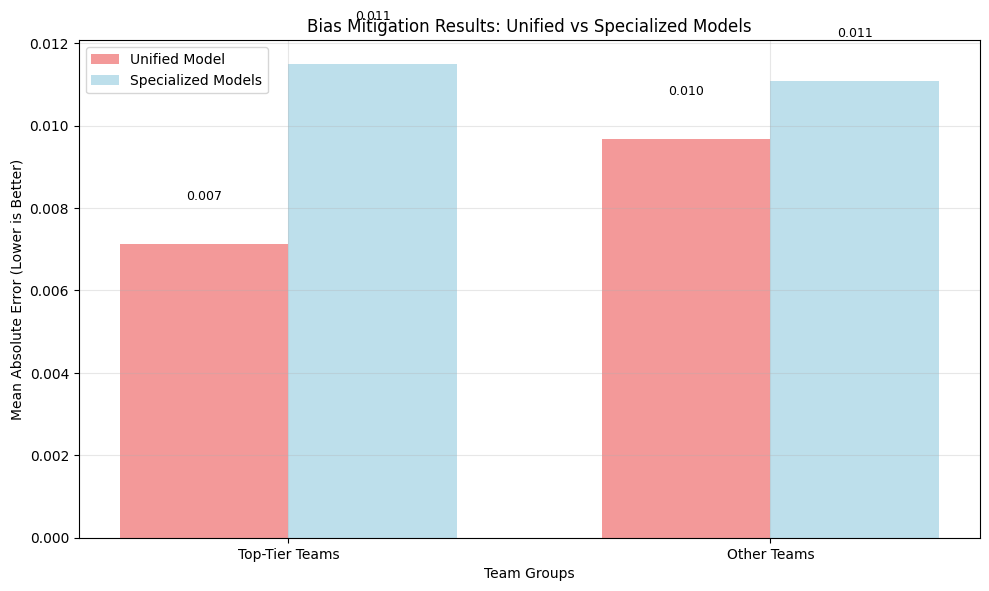


Done! 🏁


In [ ]:
"""AI F1 mentoring project FEMETRONICS WEBINAR Winter 2025 """

#Gizem Kumrili
#F1 Bias Mitigation: Training Specialized Models with Disaggregation
#Goal: Show that one AI model is biased against certain teams, then fix it by training separate models for different team groups
#Note: This approach is based on the "disaggregation" technique from fairness ML research

#Importing the Python tools (Libraries) we need
import pandas as pd #The 'pandas' library is our main tool for handling data tables (DataFrames)
from sklearn.model_selection import train_test_split #Used to split the data into trainingand testing sets
from sklearn.tree import DecisionTreeRegressor #Our specific AI model= a simple, understandable decision tree
from sklearn.metrics import mean_absolute_error #The key metric we use to measure error (MAE): the average difference between predicted and actual
import matplotlib.pyplot as plt #Used to create visual charts, like the final bar graph
import numpy as np #Used for advanced numerical operations, like creating the bar chart coordinates
"""🏁🏁🏁🏁 **IMPORTS** 🏁🏁🏁🏁
*   **pandas as pd** : handles tables of data
*   **train_test_split** : splits data into training (what the model learns from) and test (what we use later to check if it actually learned)
*   **DecisionTreeRegressor** : the type of AI model we are using, a decision tree that predicts numbers
*   **mean_absolute_error** : a way to measure how wrong our predictions are on average
*   **matplotlib.pyplot as plt** : makes graphs
*   **numpy as np** : helps with numbers and arrays """

#1. CONFIGURATION: Defining the variables and rules
#Config stuff
DATA_FILE = 'f1_pitstops_2018_2024.csv' #Defines the name of the file we are loading
TARGET_COL = 'Lap Time Variation' #Defines the column name of the "answer"

#I manually grouped these based on championship standings over the years
#Top-tier teams (usually fight for podiums)
TOP_TEAMS = ['Mercedes', 'Ferrari', 'Red Bull'] #List of teams that have cleaner, high-quality data

#Mid/lower-tier teams
OTHER_TEAMS = ['Sauber', 'Toro Rosso', 'Haas F1 Team', 'Williams', 'Force India',
               'Renault', 'AlphaTauri', 'Aston Martin', 'McLaren', 'Alpine',
               'Racing Point', 'Visa Cash App RB F1 Team', 'Stake F1 Team Kick Sauber'] #List of teams we hypothesize the AI struggles with
"""🏁🏁🏁🏁 **SECTION 1: CONFIGURATION** 🏁🏁🏁🏁

This part defines settings and assumptions for the whole experiment
****
**File and target**
- DATA_FILE = 'f1_pitstops_2018_2024.csv' (name of the CSV file that holds all your F1 pit stop data)
- TARGET_COL = 'Lap Time Variation' (column we want to predict:  how much a lap time varies/ how good or bad the lap is compared to normal)
****
 **Team groups**
- TOP_TEAMS = ['Mercedes', 'Ferrari', 'Red Bull']
- OTHER_TEAMS = [...]
Youre basically saying: These are the top-tier teams (usually more successful).
These are the other teams (mid/lower-tier).
****
**So in Section 1 we are:**
- Choosing the file
- Choosing the target variable
- Defining Top-Tier vs Other-Tier"""

#2. DATA LOADING and INITIAL CLEANING
print("Loading F1 data...") #Prints a message so we know the program is starting
#Load the dataset
try: #Starts a block to handle potential error
    df = pd.read_csv(DATA_FILE) #Loads the data file into a DataFrame named 'df'
    print(f"Loaded {len(df)} rows of data") #Reports how many rows were loaded
except FileNotFoundError: #If the file isn't there, execute this block instead
    print(f"Can't find {DATA_FILE}") # Tells the user the error
    exit() #Stops the program

#Clean up missing values in our target
original_size = len(df) #Stores the starting number of rows
df = df.dropna(subset=[TARGET_COL]) #Removes any rows where our target column is empty
dropped_rows = original_size - len(df) #Calculates how many rows were removed
if dropped_rows > 0: #If any rows were dropped, report
    print(f"Dropped {dropped_rows} rows with missing lap time data")

#Features I think are most important for predicting lap time variation
feature_cols = ['Stint Length', 'Air_Temp_C', 'Tire Compound', 'Constructor'] #List of input columns

#Keep only what we need
df_clean = df[feature_cols + [TARGET_COL]].copy() #Creates a new, clean dataframe with only the columns we need.

#FEATURE ENGINEERING: Creating the team tier (fairness label)
#Create team tier labels
def get_team_tier(constructor_name): #Defines a simple function to assign a tier label
    if constructor_name in TOP_TEAMS: #Checks if the team name is in the TOP_TEAMS list
        return 'Top_Tier' #If yes, returns this label
    else: #If not
        return 'Other_Tier' #return this label

df_clean['Team_Category'] = df_clean['Constructor'].apply(get_team_tier) #Applies the function to every row in the 'Constructor' column to create the new 'Team_Category' column

#Drop the og constructor column since we have the category now
df_clean = df_clean.drop('Constructor', axis=1) #Removes the original 'Constructor' name column (axis=1 means column)

#Convert categorical variables to numbers (one-hot encoding)
#The AI needs numbers, not text
df_encoded = pd.get_dummies(df_clean, columns=['Tire Compound', 'Team_Category'], drop_first=False) #Converts text columns like 'SOFT' or 'Top_Tier' into new columns of 1s and 0s

#Set up features and target
#Remove one of the team category columns to avoid multicollinearity issues (a math constraint for AI models)
X_columns = [col for col in df_encoded.columns if col not in [TARGET_COL, 'Team_Category_Other_Tier']]  #Defines the final list of columns for the AI's inputs (X)
X = df_encoded[X_columns] #Assigns the input columns to X
y = df_encoded[TARGET_COL] #Assigns the target column to y

print(f"Using {len(X_columns)} features: {X_columns}") #Reports the final input features list

#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #Splits X and y into training (70%) and testing (30%) sets, using '42' to ensure the split is repeatable
print(f"Training set: {len(X_train)} samples, Test set: {len(X_test)} samples") #Reports the size of the training and testing sets

print("\n" + "="*60) #Prints a separator line
print("STEP 1: Training a single 'unified' model on all data") #Header for the bias proof phase
print("="*60) #Prints a separator line

"""🏁🏁🏁🏁 **SECTION 2: DATA LOADING AND CLEANING** 🏁🏁🏁🏁
*****
1. **Start by loading our F1 data**

- print("Loading F1 data...")
- df = pd.read_csv(DATA_FILE)
- print("Loading F1 data...")

We’re asking Python to open our F1 dataset so we can work with it. If the file isn’t found, a message is shown instead of crashing.

****

2. **Remove rows that are missing the number we want to predict**
- df = df.dropna(subset=[TARGET_COL])

Our goal is to predict Lap Time Variation. If a row doesn’t have this value, the model can’t learn from it, so we delete those rows to avoid confusing the model because AI can’t learn from data with missing answers, keeping them would cause errors.
*****

3. **Choose which columns we want to use**
- feature_cols = ['Stint Length', 'Air_Temp_C', 'Tire Compound', 'Constructor']

Pick the columns that make sense for predicting lap time variation. These are what the model will look at to make a prediction.

These are the important ingredients the model uses to guess the lap time change:
- Stint length affects tyre performance
- Air temperature affects grip
- Tyre compound massively changes lap time
- Constructor (team) captures team performance differences
****

4.**Keep only the important columns**
- df_clean = df[feature_cols + [TARGET_COL]].copy()

Don’t need the whole dataset, only the columns we picked plus the answer column.
So we make a new smaller table containing ONLY the useful information. This avoids confusing the model with unnecessary data.
****

5.**Create a new column that labels each team as Top-Tier or Other-Tier**
- df_clean['Team_Category'] = df_clean['Constructor'].apply(get_team_tier)
To study fairness, we need to know which rows belong to top teams and which belong to the others. We add a new column that says ‘Top_Tier’ or ‘Other_Tier’ for each row.

We do this because:
- It lets us check if the model is fair
- It lets us measure accuracy separately for top-tier and other teams
- It helps us explore whether the AI behaves differently for different team groups
- This is the fairness label (the whole project depends on this)

We then get rid the original “Constructor” column because the team category replaces it.
****
6. **Convert text into numbers**
- df_encoded = pd.get_dummies(...)

AI models can only understand numbers, not words. So we turn words like ‘Soft Tyre’ or ‘Top_Tier’ into 0s and 1s.
****

7. **Prepare the final input (X) and answer (y) for the model**
- X = df_encoded[X_columns]
- y = df_encoded[TARGET_COL]

X is all the information the model uses to make predictions. y is the thing we want the model to predict.
****

8. **Split the data into training and testing sets**
- X_train, X_test, y_train, y_test = train_test_split(...)


Split our data into two groups:
- Training data: the model learns from this
- Test data: we hide this from the model until the end

This helps us check how well the model performs on new, unseen data.

- 70% to learn, 30% to test is a standard balance.
- Random state = 42 ensures the split is the same every time we run the code.
You can use any number.
****
9. **Start training our first model**

- print("STEP 1: Training a single 'unified' model on all data")

We’ve cleaned the data, labelled the teams, and prepared everything.
Now we are ready to train the first model (the one that will help us detect bias.)"""

#3. BIAS PROOF: Training the Single Unified Model
#Train one model on everything
unified_model = DecisionTreeRegressor(random_state=42) #Creates the Decision Tree model object
unified_model.fit(X_train, y_train) #The AI learning step= trains the model on all the training data

#Make predictions
unified_predictions = unified_model.predict(X_test) #Uses the trained model to predict the results on the unseen test data

#Need to figure out which test samples belong to which team tier
#Since we dropped 'Team_Category_Other_Tier', we use 'Team_Category_Top_Tier' to reconstruct
test_results = X_test.copy() #Creates a working copy of the test input features
test_results['actual'] = y_test #Adds the actual lap time variation results to the test copy
test_results['predicted'] = unified_predictions #Adds the AI's predicted results to the test copy
test_results['team_tier'] = np.where(test_results['Team_Category_Top_Tier'] == 1, 'Top_Tier', 'Other_Tier') #Recreates the human-readable team tier label for analysis

#Calculate error for each group
top_tier_mae = mean_absolute_error( #Calculates the error specifically for the Top-Tier samples
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'], #Actual values for Top-Tier
    test_results[test_results['team_tier'] == 'Top_Tier']['predicted'] #Predicted values for Top-Tier
)

other_tier_mae = mean_absolute_error( #Calculates the error specifically for the Other-Tier samples
    test_results[test_results['team_tier'] == 'Other_Tier']['actual'], #Actual values for Other-Tier
    test_results[test_results['team_tier'] == 'Other_Tier']['predicted'] #Predicted values for Other-Tier
)

bias_amount = abs(top_tier_mae - other_tier_mae) #Calculates the core metric of unfairness (the difference in error)

print(f"Top-tier teams MAE: {top_tier_mae:.4f}") #Prints the MAE for the first group
print(f"Other teams MAE: {other_tier_mae:.4f}") #Prints the MAE for the second group
print(f"Bias (difference): {bias_amount:.4f}") #Prints the proven amount of unfairness

if other_tier_mae > top_tier_mae: #Checks which group had the higher error (the worse performance)
    print(" The model is worse at predicting for non-top-tier teams!") #Output for the confirmation of bias
else:
    print(" The model is worse for top-tier teams")  #Alternative output

print("\n" + "="*60)
print("STEP 2: Training separate specialized models")
print("="*60)

"""🏁🏁🏁🏁 **SECTION 3: BIAS PROOF** 🏁🏁🏁🏁
*****
1. **Train a single model on all the data**

- unified_model = DecisionTreeRegressor(...) creates the model
- unified_model.fit(X_train, y_train) is where the model learns

Create one AI model that looks at all teams together.
We combine all teams first to see if a single shared model is fair or not.


****

2. **Ask the model to make predictions on new data**
- unified_predictions = unified_model.predict(X_test)

Give the model new laps it has never seen before (the test set) and ask:

‘Based on what you learned, what do you think the lap time variation will be here?’

The answers it gives are stored in unified_predictions. This is how we test how good the model is.
*****

3. **Build a results table so we can analyse fairness**
- test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = unified_predictions
test_results['team_tier'] = np.where(
    test_results['Team_Category_Top_Tier'] == 1,
    'Top_Tier', 'Other_Tier')

Create a results table called test_results.
For each row (each lap), we store:
- the input features (from X_test)
- the actual lap time variation (y_test)
- the model’s predicted value (unified_predictions)
- which team group that row belongs to: Top_Tier or Other_Tier

This table lets us compare performance separately for top-tier and other teams.

****

4.**Measure how wrong the model is for each group**
- top_tier_mae = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Top_Tier']['predicted']
)

- other_tier_mae = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Other_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Other_Tier']['predicted']
)

For each group, we calculate: 'On average, how far off are our predictions from the real values?'

That’s what MAE is:
- The difference between prediction and reality
- Make it positive (ignore +/– sign)
- Average it over all laps

A lower MAE means better predictions.

- top_tier_mae = average error for Top_Tier teams
- other_tier_mae = average error for Other_Tier team
****

5.**bias score**
- bias_amount = abs(top_tier_mae - other_tier_mae)

We ask: 'How big is the gap between the two errors?'

- If both groups have similar MAE = the model is behaving similarly for both groups = more fair.
- If there’s a big difference = one group gets worse predictions = that’s bias.

bias_amount is our bias score: difference between top-tier error and other-tier error

- If bias_amount is large = the model is unfair.
- If it’s small = the model is more fair.

****
6. **Print the results**
- print(f"Top-tier teams MAE: {top_tier_mae:.4f}")
- print(f"Other teams MAE: {other_tier_mae:.4f}")
- print(f"Bias (difference): {bias_amount:.4f}")

Print the error for both groups and the difference between them. This is our proof of whether the model is biased
****

7. **Who the model is worse for**
- if other_tier_mae > top_tier_mae:
    print(" The model is worse at predicting for non-top-tier teams!")


- else:
    print(" Interesting... the model is actually worse for top-tier teams")


This is where we state the bias explicitly.
****
8. **Fixing the bias**
- print("\n" + "="*60)
- print("STEP 2: Training separate specialized models")
- print("="*60)

Moving to fixing the bias..."""

# 4. BIAS MITIGATION: Splitting and Training Specialized Models
#Prepare training data with target included for easy filtering
train_data = X_train.copy() #Creates a copy of the training input features
train_data['target'] = y_train #Adds the actual target values to the training data copy

#Split training data by team tier
top_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 1] #Filters the training data to include ONLY Top-Tier samples
other_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 0] #Filters the training data to include ONLY Other-Tier samples

print(f"Top-tier training samples: {len(top_tier_train)}") #Reports the size of the Top-Tier training data
print(f"Other-tier training samples: {len(other_tier_train)}") #Reports the size of the Other-Tier training data

#Features for specialized models (exclude team category info)
specialized_features = [col for col in train_data.columns #Defines the final list of inputs for the two new models
                        if col not in ['target', 'Team_Category_Top_Tier', 'Team_Category_Other_Tier']] #EXCLUDES the team category, forcing the models to focus on conditions

#Train model for top-tier teams
X_top = top_tier_train[specialized_features] #Inputs for the Top-Tier model
y_top = top_tier_train['target'] #Target for the Top-Tier model
model_top = DecisionTreeRegressor(random_state=42) #Creates the Top-Tier model object
model_top.fit(X_top, y_top) #The AI learning step= trains Model Top only on Top-Tier data

#Train model for other teams
X_other = other_tier_train[specialized_features] #Inputs for the Other-Tier model
y_other = other_tier_train['target'] #Target for the Other-Tier model
model_other = DecisionTreeRegressor(random_state=50) #Creates the Other-Tier model object
model_other.fit(X_other, y_other) #The AI learning step=trains Model Other only on Other-Tier data

print("Trained both specialized models") #Confirms both models are now trained

#Test the specialized models
test_features = test_results[specialized_features] #Gets the common input features for prediction

#Apply the right model to each test sample
specialized_preds = [] #Creates an empty list to store the predictions from the two models
for idx, row in test_results.iterrows(): #Loops through every single row (lap) in the test data
    if row['team_tier'] == 'Top_Tier': #Checks if this lap belongs to a Top-Tier team
        pred = model_top.predict(test_features.loc[idx:idx])[0] #If yes, uses the TOP-TIER model for prediction
    else: #If no (it must be an Other-Tier team), uses the OTHER-TIER model for prediction
        pred = model_other.predict(test_features.loc[idx:idx])[0]
    specialized_preds.append(pred) #Adds the prediction to the list

test_results['specialized_pred'] = specialized_preds #Adds the final list of predictions to the test results df



""""🏁🏁🏁🏁 **SECTION 4: BIAS MITIGATION** 🏁🏁🏁🏁

Before, we had one model for everyone. Now we create two separate models: one just for top-tier teams, one just for other teams
*****
1. **Put the training inputs and targets together**

- train_data = X_train.copy()
- train_data['target'] = y_train

Take our training data (X_train) and attach the correct answer (y_train) to it in a new column called target.

Each row in train_data contains:
- the input features (stint length, tyre, temp, etc.)
- the actual lap time variation (target)

This makes it easier to filter and split.


****

2. **Split the training data into two groups**
- top_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 1]
- other_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 0]

Split the training data into two separate tables:
- top_tier_train: these are top teams laps
- other_tier_train: these are other teams laps

*****

3. **Decide which features the specialised models are allowed to use**
- specialized_features = [
    col for col in train_data.columns
    if col not in ['target', 'Team_Category_Top_Tier', 'Team_Category_Other_Tier']
]

Choose which columns (features) our new models should use.

Remove:
- target because that’s the thing we’re trying to predict, not an input
- Team_Category_Top_Tier and Team_Category_Other_Tier because these say whether a row is top-tier or not. We don’t want the models to directly use the group label (‘Top’ vs ‘Other’).

We want to focus on driving conditions like:
- stint length
- tyre compound
- air temperature

That way, the models is learning patterns from the actual race conditions rather than memorising which team is better.

****

4.**Train a model just for top-tier teams**
- X_top = top_tier_train[specialized_features]
y_top = top_tier_train['target']
model_top = DecisionTreeRegressor(random_state=42)
model_top.fit(X_top, y_top)

Create a specialist model that only learns from top-tier teams:
-X_top = the inputs (only laps from top-tier teams)
- y_top = the correct lap time variation for those laps


- model_top.fit(X_top, y_top)

Teaches the model: ‘Given these conditions (tyre, stint, temp) for top-tier teams, what does lap time variation usually look like?’

****

5.**Train a model for other teams**
same process as 4.

****
6. **Get test features ready**
- test_features = test_results[specialized_features]

Prepare the test data using the same features we chose for training. test_features is what we’ll feed into the specialised models to get predictions.
****

7. **Using the right model for each test lap**
- specialized_preds = []

for idx, row in test_results.iterrows():
    if row['team_tier'] == 'Top_Tier':
        pred = model_top.predict(test_features.loc[idx:idx])[0]
    else:
        pred = model_other.predict(test_features.loc[idx:idx])[0]
    specialized_preds.append(pred)

test_results['specialized_pred'] = specialized_preds


Go through every test lap, one by one:
- If the lap belongs to a Top-Tier team: we send it to model_top. We get a prediction from the top-team specialist.
- If the lap belongs to an Other-Tier team: we send it to model_other. We get a prediction from the other-team specialist

Each prediction is stored in a list called specialized_preds. At the end, we add these predictions to test_results in a new column:
- test_results['specialized_pred'] = specialized_preds

So now test_results has:
- the actual value (actual)
- the unified model prediction (predicted)
- the specialised model prediction (specialized_pred)
- the team tier (team_tier)"""

#5. MITIGATION EVALUATION: Checking the new models for fairness
#Calculate new MAE values
top_tier_mae_specialized = mean_absolute_error( #Calculates the error for the Top-Tier group using its specialized model
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Top_Tier']['specialized_pred']
)

other_tier_mae_specialized = mean_absolute_error( #Calculates the error for the Other-Tier group using its specialized model
    test_results[test_results['team_tier'] == 'Other_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Other_Tier']['specialized_pred']
)

new_bias = abs(top_tier_mae_specialized - other_tier_mae_specialized) #Calculates the NEW amount of unfairness (the new difference in error)

print(f"\nSpecialized models results:") #Prints the header for the new results
print(f"Top-tier teams MAE: {top_tier_mae_specialized:.4f}") #Prints the new Top-Tier MAE
print(f"Other teams MAE: {other_tier_mae_specialized:.4f}") #Prints the new Other-Tier MAE
print(f"New bias: {new_bias:.4f}") #Prints the new difference



"""🏁🏁🏁🏁 **SECTION 5: MITIGATION EVALUATION** 🏁🏁🏁🏁

This section answers one big question: “After training two specialised models, are the predictions now more fair?” Just like in Section 3, we compare errors between:
- Top-Tier teams
- Other-Tier teams

…But this time using the specialised models predictions, not the unified model.
*****
1. **Measure how wrong the specialised model is for Top-Tier teams**

- top_tier_mae_specialized = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Top_Tier']['specialized_pred']
)

Look only at the test laps belonging to Top-Tier teams. We compare:
- the real lap time variation (actual)
- the prediction from the top-tier specialised model (specialized_pred)

We calculate the Mean Absolute Error (MAE) again (MAE = how wrong the predictions are on average)  This gives us the new error for top-tier teams after bias mitigation.

****

2. **Measure how wrong the specialised model is for other teams**

Same process as 1.

*****

3. **Compute the new bias score**
- new_bias = abs(top_tier_mae_specialized - other_tier_mae_specialized)

To measure unfairness, we take the difference between the two errors:

- Bias =  error for Top-Tier – error for Other-Tier

If this number goes DOWN compared to the unified model, our bias mitigation worked.

- If new bias < old bias, fairness improved
- If new bias > old bias, fairness got worse

This is the moment our project proves whether the fix actually worked.

****

4.**Print the results**

updated numbers:
- the new error for top-tier teams
- the new error for other teams
- the new bias score"""

# 6. FINAL REPORT and VISUALIZATION
#Report
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

comparison_df = pd.DataFrame({ #Creates a summary table to compare the two approaches
    'Team Group': ['Top-Tier Teams', 'Other Teams', 'Bias (Difference)'],
    'Unified Model': [top_tier_mae, other_tier_mae, bias_amount], #Data from the initial biased model
    'Specialized Models': [top_tier_mae_specialized, other_tier_mae_specialized, new_bias] #Data from the fixed specialized models
})

print(comparison_df.to_string(index=False, float_format='%.4f')) #Prints the clean comparison table

bias_reduction = ((bias_amount - new_bias) / bias_amount) * 100 if bias_amount > 0 else 0 #Calculates the percentage reduction in unfairness
print(f"\nBias reduction: {bias_reduction:.1f} %") #Reports the final success metric

 #Checks if the fix worked
if new_bias < bias_amount:
    print("Success! Specialized models reduced bias") #Success message
else:
    print("Specialized models didn't help much") #Failure message

#Visualization
fig, ax = plt.subplots(figsize=(10, 6)) #Setting up the bar chart figure

groups = ['Top-Tier Teams', 'Other Teams'] #Labels for the x-axis
unified_errors = [top_tier_mae, other_tier_mae] #Errors for the first set of bars (Unified)
specialized_errors = [top_tier_mae_specialized, other_tier_mae_specialized] # #Errors for the second set of bars (Specialized)

x_pos = np.arange(len(groups)) #Sets up the positions for the bars
width = 0.35 #Defines the width of each bar

bars1 = ax.bar(x_pos - width/2, unified_errors, width, #Draws the bars for the Unified Model
               label='Unified Model', color='lightcoral', alpha=0.8) #Sets color, label and transparency
bars2 = ax.bar(x_pos + width/2, specialized_errors, width, #Draws the bars for the specialized models
               label='Specialized Models', color='lightblue', alpha=0.8) #Sets color, label and transparency

ax.set_xlabel('Team Groups') #Sets the label for the horizontal axis
ax.set_ylabel('Mean Absolute Error') #Sets the label for the vertical axis
ax.set_title('Bias Mitigation Results: Unified vs Specialized Models') #Sets the main chart title
ax.set_xticks(x_pos) #Defines where the x-axis ticks should go
ax.set_xticklabels(groups) #Labels the x-axis ticks with the group names
ax.legend() #Displays the legend (Unified vs. Specialized)
ax.grid(True, alpha=0.3)  #Checks if the fix worked

#Add value labels on bars
for bar in bars1: #Loop through the Unified Model bars
    height = bar.get_height() #Get the height (MAE value) of the bar
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001, #Position the text slightly above the bar
            f'{height:.3f}', ha='center', va='bottom', fontsize=9) #Formats the text as MAE value

for bar in bars2: #Loop through the Specialized Model bars
    height = bar.get_height() #Get the height (MAE value) of the bar
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001, #Position the text slightly above the bar
            f'{height:.3f}', ha='center', va='bottom', fontsize=9) #Formats the text as MAE value

plt.tight_layout() #Adjusts layout to prevent labels from overlapping
plt.show() #Displays the final chart

"""🏁🏁🏁🏁**SECTION 6: REPORT AND VISUALISATION** 🏁🏁🏁🏁

*****
1. **REPORT**

Printed:

A. Comparison table that compares:
- The unified model (one model for everyone)
- The specialised models (one for top-tier, one for other teams)

For three rows:
- Error for Top-Tier Teams
- Error for Other Teams
- The bias (difference between the two errors)

This makes it very easy to see:
- Which model had higher error
- Whether the bias went down when using specialised models

B. % of bias removed

formula:
- Old bias = bias_amount
- New bias = new_bias
- Bias reduction % = (old – new) / old × 100


C. Clearly stated if the fix worked or not.

****

2. **VISUALISATION**

Prepared:
- the chart (drawing, labelling and positioning)

- data for the bars ( to show two bars for each group: one for the unified model’s error, one for the specialised models’ error. We define:
which groups we have on the x-axis (Top-Tier, Other Teams), the errors for those groups with the unified model and the errors for those groups with the specialised models)

🏁🏁🏁🏁 **EXPLANATION OF THE RESULTS** 🏁🏁🏁🏁

Summary:
- loaded 7,374 F1 pit stop/lap records from 2018 to 2024. Some rows didn’t have a lap time value, so we removed 185 of them (AI can’t learn from missing answers)

- trained the model using 5,032 laps and tested it on 2,157 new laps it had never seen. This is like training a driver on one set of tracks and then seeing how they perform on a brand-new circuit

****
- MAE means how wrong the model is on average. 0.0071 means it was only 0.0071 seconds off for top teams. 0.0097 means it was 0.0097 seconds off for other teams. The model predicts lap time variation more accurately for big teams like Ferrari, Mercedes, and Red Bull

- The difference between the errors is 0.0025 seconds.
That may look small, but in F1, 2.5 milliseconds can easily be the difference between: a clean lap and a bad prediction that misleads race strategy. So the model is unfair, because it predicts worse for smaller teams

****
- We gave the top-team model 1,564 laps to learn from.
We gave the other-teams model 3,468 laps. Each model learns patterns specific to its group

-With specialised models: Both groups have almost the same error. The predictions are now equally fair. The small teams no longer get worse predictions than the big teams. Both groups now have lap predictions within about 0.011 seconds, like two drivers being almost neck-and-neck across the finish line

****
What the Unified Model Bars Mean:

 Unified Model bars (red):
- Top-Tier error ≈ 0.007 seconds
- Other-Team error ≈ 0.010 seconds

Meaning: The unified model makes better predictions for top-tier teams and worse predictions for smaller teams. This shows bias, because the model is not equally accurate for both groups.

Specialised Models bars (blue):
- Both errors ≈ 0.011 seconds
- Very close to each other (0.0115 vs 0.0111)

Meaning: The specialised models make predictions that are almost equally accurate for both groups. The errors for top teams and other teams are now almost the same.
This means fairness improved.
"""


🏁🏁🏁🏁 **IMPORTS** 🏁🏁🏁🏁

*   **pandas as pd** : handles tables of data
*   **train_test_split** : splits data into training (what the model learns from) and test (what we use later to check if it actually learned)
*   **DecisionTreeRegressor** : the type of AI model we are using, a decision tree that predicts numbers
*   **mean_absolute_error** : a way to measure how wrong our predictions are on average
*   **matplotlib.pyplot as plt** : makes graphs
*   **numpy as np** : helps with numbers and arrays

 🏁🏁🏁🏁 **SECTION 1: CONFIGURATION** 🏁🏁🏁🏁

This part defines settings and assumptions for the whole experiment
****
**File and target**
- DATA_FILE = 'f1_pitstops_2018_2024.csv' (name of the CSV file that holds all your F1 pit stop data)
- TARGET_COL = 'Lap Time Variation' (column we want to predict:  how much a lap time varies/ how good or bad the lap is compared to normal)
****
 **Team groups**
- TOP_TEAMS = ['Mercedes', 'Ferrari', 'Red Bull']
- OTHER_TEAMS = [...]
Youre basically saying: These are the top-tier teams (usually more successful).
These are the other teams (mid/lower-tier).
****
**So in Section 1 we are:**
- Choosing the file
- Choosing the target variable
- Defining Top-Tier vs Other-Tier

🏁🏁🏁🏁 **SECTION 2: DATA LOADING AND CLEANING** 🏁🏁🏁🏁
*****
1. **Start by loading our F1 data**

- print("Loading F1 data...")
- df = pd.read_csv(DATA_FILE)
- print("Loading F1 data...")

We’re asking Python to open our F1 dataset so we can work with it. If the file isn’t found, a message is shown instead of crashing.

****

2. **Remove rows that are missing the number we want to predict**
- df = df.dropna(subset=[TARGET_COL])

Our goal is to predict Lap Time Variation. If a row doesn’t have this value, the model can’t learn from it, so we delete those rows to avoid confusing the model because AI can’t learn from data with missing answers, keeping them would cause errors.
*****

3. **Choose which columns we want to use**
- feature_cols = ['Stint Length', 'Air_Temp_C', 'Tire Compound', 'Constructor']

Pick the columns that make sense for predicting lap time variation. These are what the model will look at to make a prediction.

These are the important ingredients the model uses to guess the lap time change:
- Stint length affects tyre performance
- Air temperature affects grip
- Tyre compound massively changes lap time
- Constructor (team) captures team performance differences
****

4.**Keep only the important columns**
- df_clean = df[feature_cols + [TARGET_COL]].copy()

Don’t need the whole dataset, only the columns we picked plus the answer column.
So we make a new smaller table containing ONLY the useful information. This avoids confusing the model with unnecessary data.
****

5.**Create a new column that labels each team as Top-Tier or Other-Tier**
- df_clean['Team_Category'] = df_clean['Constructor'].apply(get_team_tier)
To study fairness, we need to know which rows belong to top teams and which belong to the others. We add a new column that says ‘Top_Tier’ or ‘Other_Tier’ for each row.

We do this because:
- It lets us check if the model is fair
- It lets us measure accuracy separately for top-tier and other teams
- It helps us explore whether the AI behaves differently for different team groups
- This is the fairness label (the whole project depends on this)

We then get rid the original “Constructor” column because the team category replaces it.
****
6. **Convert text into numbers**
- df_encoded = pd.get_dummies(...)

AI models can only understand numbers, not words. So we turn words like ‘Soft Tyre’ or ‘Top_Tier’ into 0s and 1s.
****

7. **Prepare the final input (X) and answer (y) for the model**
- X = df_encoded[X_columns]
- y = df_encoded[TARGET_COL]

X is all the information the model uses to make predictions. y is the thing we want the model to predict.
****

8. **Split the data into training and testing sets**
- X_train, X_test, y_train, y_test = train_test_split(...)


Split our data into two groups:
- Training data: the model learns from this
- Test data: we hide this from the model until the end

This helps us check how well the model performs on new, unseen data.

- 70% to learn, 30% to test is a standard balance.
- Random state = 42 ensures the split is the same every time we run the code.
You can use any number.
****
9. **Start training our first model**

- print("STEP 1: Training a single 'unified' model on all data")

We’ve cleaned the data, labelled the teams, and prepared everything.
Now we are ready to train the first model (the one that will help us detect bias.)

🏁🏁🏁🏁 **SECTION 3: BIAS PROOF** 🏁🏁🏁🏁
*****
1. **Train a single model on all the data**

- unified_model = DecisionTreeRegressor(...) creates the model
- unified_model.fit(X_train, y_train) is where the model learns

Create one AI model that looks at all teams together.
We combine all teams first to see if a single shared model is fair or not.


****

2. **Ask the model to make predictions on new data**
- unified_predictions = unified_model.predict(X_test)

Give the model new laps it has never seen before (the test set) and ask:

‘Based on what you learned, what do you think the lap time variation will be here?’

The answers it gives are stored in unified_predictions. This is how we test how good the model is.
*****

3. **Build a results table so we can analyse fairness**
- test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = unified_predictions
test_results['team_tier'] = np.where(
    test_results['Team_Category_Top_Tier'] == 1,
    'Top_Tier', 'Other_Tier')

Create a results table called test_results.
For each row (each lap), we store:
- the input features (from X_test)
- the actual lap time variation (y_test)
- the model’s predicted value (unified_predictions)
- which team group that row belongs to: Top_Tier or Other_Tier

This table lets us compare performance separately for top-tier and other teams.

****

4.**Measure how wrong the model is for each group**
- top_tier_mae = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Top_Tier']['predicted']
)

- other_tier_mae = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Other_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Other_Tier']['predicted']
)

For each group, we calculate: 'On average, how far off are our predictions from the real values?'

That’s what MAE is:
- The difference between prediction and reality
- Make it positive (ignore +/– sign)
- Average it over all laps

A lower MAE means better predictions.

- top_tier_mae = average error for Top_Tier teams
- other_tier_mae = average error for Other_Tier team
****

5.**bias score**
- bias_amount = abs(top_tier_mae - other_tier_mae)

We ask: 'How big is the gap between the two errors?'

- If both groups have similar MAE = the model is behaving similarly for both groups = more fair.
- If there’s a big difference = one group gets worse predictions = that’s bias.

bias_amount is our bias score: difference between top-tier error and other-tier error

- If bias_amount is large = the model is unfair.
- If it’s small = the model is more fair.

****
6. **Print the results**
- print(f"Top-tier teams MAE: {top_tier_mae:.4f}")
- print(f"Other teams MAE: {other_tier_mae:.4f}")
- print(f"Bias (difference): {bias_amount:.4f}")

Print the error for both groups and the difference between them. This is our proof of whether the model is biased
****

7. **Who the model is worse for**
- if other_tier_mae > top_tier_mae:
    print(" The model is worse at predicting for non-top-tier teams!")
    

- else:
    print(" Interesting... the model is actually worse for top-tier teams")


This is where we state the bias explicitly.
****
8. **Fixing the bias**
- print("\n" + "="*60)
- print("STEP 2: Training separate specialized models")
- print("="*60)

Moving to fixing the bias...




🏁🏁🏁🏁 **SECTION 4: BIAS MITIGATION** 🏁🏁🏁🏁

Before, we had one model for everyone. Now we create two separate models: one just for top-tier teams, one just for other teams
*****
1. **Put the training inputs and targets together**

- train_data = X_train.copy()
- train_data['target'] = y_train

Take our training data (X_train) and attach the correct answer (y_train) to it in a new column called target.

Each row in train_data contains:
- the input features (stint length, tyre, temp, etc.)
- the actual lap time variation (target)

This makes it easier to filter and split.


****

2. **Split the training data into two groups**
- top_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 1]
- other_tier_train = train_data[train_data['Team_Category_Top_Tier'] == 0]

Split the training data into two separate tables:
- top_tier_train: these are top teams laps
- other_tier_train: these are other teams laps

*****

3. **Decide which features the specialised models are allowed to use**
- specialized_features = [
    col for col in train_data.columns
    if col not in ['target', 'Team_Category_Top_Tier', 'Team_Category_Other_Tier']
]

Choose which columns (features) our new models should use.

Remove:
- target because that’s the thing we’re trying to predict, not an input
- Team_Category_Top_Tier and Team_Category_Other_Tier because these say whether a row is top-tier or not. We don’t want the models to directly use the group label (‘Top’ vs ‘Other’).

We want to focus on driving conditions like:
- stint length
- tyre compound
- air temperature

That way, the models is learning patterns from the actual race conditions rather than memorising which team is better.

****

4.**Train a model just for top-tier teams**
- X_top = top_tier_train[specialized_features]
y_top = top_tier_train['target']
model_top = DecisionTreeRegressor(random_state=42)
model_top.fit(X_top, y_top)

Create a specialist model that only learns from top-tier teams:
-X_top = the inputs (only laps from top-tier teams)
- y_top = the correct lap time variation for those laps


- model_top.fit(X_top, y_top)

Teaches the model: ‘Given these conditions (tyre, stint, temp) for top-tier teams, what does lap time variation usually look like?’

****

5.**Train a model for other teams**
same process as 4.

****
6. **Get test features ready**
- test_features = test_results[specialized_features]

Prepare the test data using the same features we chose for training. test_features is what we’ll feed into the specialised models to get predictions.
****

7. **Using the right model for each test lap**
- specialized_preds = []

for idx, row in test_results.iterrows():
    if row['team_tier'] == 'Top_Tier':
        pred = model_top.predict(test_features.loc[idx:idx])[0]
    else:
        pred = model_other.predict(test_features.loc[idx:idx])[0]
    specialized_preds.append(pred)

test_results['specialized_pred'] = specialized_preds


Go through every test lap, one by one:
- If the lap belongs to a Top-Tier team: we send it to model_top. We get a prediction from the top-team specialist.
- If the lap belongs to an Other-Tier team: we send it to model_other. We get a prediction from the other-team specialist

Each prediction is stored in a list called specialized_preds. At the end, we add these predictions to test_results in a new column:
- test_results['specialized_pred'] = specialized_preds

So now test_results has:
- the actual value (actual)
- the unified model prediction (predicted)
- the specialised model prediction (specialized_pred)
- the team tier (team_tier)





🏁🏁🏁🏁 **SECTION 5: MITIGATION EVALUATION** 🏁🏁🏁🏁

This section answers one big question: “After training two specialised models, are the predictions now more fair?” Just like in Section 3, we compare errors between:
- Top-Tier teams
- Other-Tier teams

…But this time using the specialised models predictions, not the unified model.
*****
1. **Measure how wrong the specialised model is for Top-Tier teams**

- top_tier_mae_specialized = mean_absolute_error(
    test_results[test_results['team_tier'] == 'Top_Tier']['actual'],
    test_results[test_results['team_tier'] == 'Top_Tier']['specialized_pred']
)

Look only at the test laps belonging to Top-Tier teams. We compare:
- the real lap time variation (actual)
- the prediction from the top-tier specialised model (specialized_pred)

We calculate the Mean Absolute Error (MAE) again (MAE = how wrong the predictions are on average)  This gives us the new error for top-tier teams after bias mitigation.

****

2. **Measure how wrong the specialised model is for other teams**

Same process as 1.

*****

3. **Compute the new bias score**
- new_bias = abs(top_tier_mae_specialized - other_tier_mae_specialized)

To measure unfairness, we take the difference between the two errors:

- Bias =  error for Top-Tier – error for Other-Tier

If this number goes DOWN compared to the unified model, our bias mitigation worked.

- If new bias < old bias, fairness improved
- If new bias > old bias, fairness got worse

This is the moment our project proves whether the fix actually worked.

****

4.**Print the results**

updated numbers:
- the new error for top-tier teams
- the new error for other teams
- the new bias score



🏁🏁🏁🏁**SECTION 6: REPORT AND VISUALISATION** 🏁🏁🏁🏁

*****
1. **REPORT**

Printed:

A. Comparison table that compares:
- The unified model (one model for everyone)
- The specialised models (one for top-tier, one for other teams)

For three rows:
- Error for Top-Tier Teams
- Error for Other Teams
- The bias (difference between the two errors)

This makes it very easy to see:
- Which model had higher error
- Whether the bias went down when using specialised models

B. % of bias removed

formula:
- Old bias = bias_amount
- New bias = new_bias
- Bias reduction % = (old – new) / old × 100


C. Clearly stated if the fix worked or not.

****

2. **VISUALISATION**

Prepared:
- the chart (drawing, labelling and positioning)

- data for the bars ( to show two bars for each group: one for the unified model’s error, one for the specialised models’ error. We define:
which groups we have on the x-axis (Top-Tier, Other Teams), the errors for those groups with the unified model and the errors for those groups with the specialised models)


🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁🏁

🏁🏁🏁🏁 **EXPLANATION OF THE RESULTS** 🏁🏁🏁🏁

Summary:
- loaded 7,374 F1 pit stop/lap records from 2018 to 2024. Some rows didn’t have a lap time value, so we removed 185 of them (AI can’t learn from missing answers)

- trained the model using 5,032 laps and tested it on 2,157 new laps it had never seen. This is like training a driver on one set of tracks and then seeing how they perform on a brand-new circuit

****
- MAE means how wrong the model is on average. 0.0071 means it was only 0.0071 seconds off for top teams. 0.0097 means it was 0.0097 seconds off for other teams. The model predicts lap time variation more accurately for big teams like Ferrari, Mercedes, and Red Bull

- The difference between the errors is 0.0025 seconds.
That may look small, but in F1, 2.5 milliseconds can easily be the difference between: a clean lap and a bad prediction that misleads race strategy. So the model is unfair, because it predicts worse for smaller teams

****
- We gave the top-team model 1,564 laps to learn from.
We gave the other-teams model 3,468 laps. Each model learns patterns specific to its group

-With specialised models: Both groups have almost the same error. The predictions are now equally fair. The small teams no longer get worse predictions than the big teams. Both groups now have lap predictions within about 0.011 seconds, like two drivers being almost neck-and-neck across the finish line

****
What the Unified Model Bars Mean:

🟥 Unified Model bars (red):
- Top-Tier error ≈ 0.007 seconds
- Other-Team error ≈ 0.010 seconds

Meaning: The unified model makes better predictions for top-tier teams and worse predictions for smaller teams. This shows bias, because the model is not equally accurate for both groups.

🟦 Specialised Models bars (blue):
- Both errors ≈ 0.011 seconds
- Very close to each other (0.0115 vs 0.0111)

Meaning: The specialised models make predictions that are almost equally accurate for both groups. The errors for top teams and other teams are now almost the same.
This means fairness improved.